# Embedding Approach for Protein Families Prediction

Authors: <br>Shatu Ahmed <br> Anna Beketova

[Gitlab repository](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/main/Embedding?ref_type=heads)

## Introduction

Embedding is the way of displaying objects as numerical vectors, that include their properties and relationships with other objects. Such vectors are used for machine learning and contribute to data analysis.
<p> The main goal of embedding is to show mathematically the similarity and diferences between objects. The embedding approach helps model to recognize similar objects, comparing their vectors.
<p> In the context of bioinformatics the protein sequences are embedded, where each aminoacid is translated into its numerical Kidera factor. It would help to determine proteins that have similar structure and physical properties to the corresponding protein family.
<p> The protein data was preprocessed, embedded using Kidera factors, and two models were meant to be trained - Logistical Regression and Random Forest.

## Material & Methods

### Material
<p>Provided data:
<ul>
  
  <li> *mapmanreferencebins.results.txt* - mapman table of proteins
  <li> *protein.fa* - protein sequences
  <li> both files in .tar archive *Mapman_reference_DB_202310.tar.bz2*
 </ul>
 <ul>
  <li> *properties.188.csv* - all the amino acids' properties used in Kidera Paper
</ul>


### Methods

all used scrips can be found in the [methods](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/main/Embedding/methods?ref_type=heads) directory of the above mentioned gitlab repository


#### Data Extraction & Preprocessing

The data was extracted from the .tar file, using `tar xjf <filename>` bash command.
<p> *mapmanreferencebins.results.txt* file was preprocessed using *preprocessing.py* script: The protein family names and their ids were extracted and saved as a dictionary. The data was grouped by protein families, and an aminoacid sequence was assigned to each protein. The result was saved as *labeled_sequences.csv*.
<p> The labeled file contained ','-symbol as a delimiter. To prevent issues from arising where a comma would be seen as additional columns, these columns would be merged. The final preprocessed result was saved as *cleaned_labeled_sequences.csv* file.



In [ ]:
import pandas as pd
from Bio import SeqIO
import csv

#read data
data = pd.read_csv("mapmanreferencebins.results.txt", sep="\t")

family_dict = {} # dictionary to store all identifiers of each family


for index, row in data.iterrows():
    family = row['NAME'].strip("'")
    protein_id = row['IDENTIFIER'].strip("'").lower()
    if(protein_id):
        if(family not in family_dict):
            family_dict[family] = []
        family_dict[family].append(protein_id)


print(sum(len(v) for v in family_dict.values()))

proteins = "protein.fa"
protein_dict = {}

for record in SeqIO.parse(proteins, "fasta"):
    uniprot_id = record.id.split("|")[-1].lower()
    sequence = str(record.seq)
    protein_dict[uniprot_id] = sequence

grouped_dict = {}
for family, protein_ids in family_dict.items():
    sequences = [protein_dict[p] for p in protein_ids if p in protein_dict]
    if sequences:
        grouped_dict[family] = sequences
    else:
        grouped_dict[family] = []

result = "labeled_sequences.csv"
with open(result, "w") as newfile:
    newfile.write("family,sequence\n")
    for family, sequences in grouped_dict.items():
        for seq in sequences:
            newfile.write(f"{family}, {seq}\n")


cleaned_rows = []

with open("labeled_sequences.csv", "r") as infile:
    reader = csv.reader(infile)
    for row in reader:
        if len(row) > 2:
            family = row[0]
            sequence = ''.join(row[1:]).replace('"', '').replace("'", "") # Merge falsly added columns and clean quotes
            cleaned_rows.append([family, sequence])
        elif len(row) == 2:
            cleaned_rows.append(row)
        else:
            print(f"Skipping malformed row: {row}")


with open("cleaned_labeled_sequences.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_rows)

print("done")

#### Embedding

For the embedding, the first 10 Kidera values from the _properties.188.csv_ file for each aminoacid sequence were used:
<ul>
    <li> Molecular weight (Fasman, 1976)
    <li> Residue accessible surface area in tripeptide (Chothia, 1976)
    <li> Volume (Grantham, 1974)
    <li> Short and medium range non-bonded energy per residue (Oobatake-Ooi, 1977)
    <li> Side chain volume (Krigbaum-Komoriya, 1979)
    <li> Distance between C-alpha and centroid of side chain (Levitt, 1976)
    <li> Radius of gyration of side chain (Levitt, 1976)
    <li> Residue volume (Bigelow, 1967)
    <li> Residue volume (Goldsack-Chalifoux, 1973)
    <li> Transfer free energy to lipophilic phase (von Heijne-Blomberg, 1979)
</ul>
<p> For machine learning model, a fixed-size-embedding is preferred. The cleaned_labeled_sequences.csv file was parced, and a single averaged Kidera embedding vector for the entire sequence was computed
<p> The embedded sequences were saved as the embedded_proteins.csv file.

In [ ]:
import numpy as np
import csv


amino_acids_ki_factor = {
    'A' : [89.09,115,31,-7.020,27.5,0.77,0.77,52.6,88.3,-12.04],
    'R' : [174.20,225,124,-10.131,105.0,3.72,2.38,109.1,181.2,39.23],
    'N' : [132.12,160, 56,-9.424,58.7, 1.98,1.45,75.7,125.1,4.25],
    'D' : [133.1,150,54.,-9.296,40.0,1.99,1.43,68.4,110.8,23.22],
    'C' : [121.15,135,55,-8.190,44.6,1.38,1.22,68.3,112.4,3.95],
    'Q' : [146.15,180,85,-10.044,80.7,2.58,1.75,89.7,148.7,2.16],
    'E' : [147.13,190,83,-10.467,62.0,2.63,1.77,84.7,140.5,16.81],
    'G' : [75.07,75,3,-5.456,0.0,0.00,0.58,36.3,60.0,-7.85],
    'H': [155.16, 195.0, 96.0, -12.15, 79.0, 2.76, 1.78, 91.9, 152.6, 6.28],
    'I': [131.17, 175.0, 111.0, -9.512, 93.5, 1.83, 1.56, 102.0, 168.5, -18.32],
    'L': [131.17, 170.0, 111.0, -10.52, 93.5, 2.08, 1.54, 102.0, 168.5, -17.79],
    'K': [146.19, 200.0, 119.0, -9.666, 100.0, 2.94, 2.08, 105.1, 175.6, 9.71],
    'M': [149.21, 185.0, 105.0, -10.424, 94.1, 2.34, 1.8, 97.7, 162.2, -8.86],
    'F': [165.19, 210.0, 132.0, -12.485, 115.5, 2.97, 1.9, 113.9, 189.0, -21.98],
    'P': [115.13, 145.0, 32.5, -8.652, 41.9, 1.42, 1.25, 73.6, 122.2, 5.82],
    'S': [105.09, 115.0, 32.0, -7.782, 29.3, 1.28, 1.08, 54.9, 88.7, -1.54],
    'T': [119.12, 140.0, 61.0, -8.764, 51.3, 1.43, 1.24, 71.2, 118.2, -4.15],
    'W': [204.24, 255.0, 170.0, -14.42, 145.5, 3.58, 2.21, 135.4, 227.0, -16.19],
    'Y': [181.19, 230.0, 136.0, -12.36, 117.3, 3.36, 2.13, 116.2, 193.0, -1.51],
    'V': [117.15, 155.0, 84.0, -8.778, 71.5, 1.49, 1.29, 85.1, 141.4, -16.22]

}

# Default vector for unknown amino acids
default_kidera_vector = np.zeros(10)

def compute_kidera_embedding(sequence):
    factors = [amino_acids_ki_factor.get(aa, default_kidera_vector) for aa in sequence]
    # Calculate the mean of the vector (embedding) for each amino acid
    return np.mean(factors, axis=0) if factors else default_kidera_vector #returns zero vector if the sequence is empty


#embedding process

input = "cleaned_labeled_sequences.csv"
output = "embedded_proteins.csv"

embeddings = []

with open("cleaned_labeled_sequences.csv", "r") as file:
    reader = csv.reader(file)
    next(reader)  # Skip header
    for family, sequence in reader:
        embedding = compute_kidera_embedding(sequence.strip())
        embeddings.append((family.strip(), embedding))


feature_dict = ["Molecular weight", "Residue accessible surface area in tripeptide", "Volume",
                  "Short and medium range non-bonded energy per residue", "Side chain volume",
                  "Distance between C-alpha and centroid of side chain",
                  "Radius of gyration of side chain", "Residue volume_B", "Residue volume_GC",
                  "Transfer free energy to lipophilic phase" ]

  # Save the embeddings to a new CSV file
with open("embedded_proteins.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerow(["family"] + feature_dict)  # Header
    for family, embedding in embeddings:
        writer.writerow([family] + embedding.tolist())


The output contains a single 10-dimensional vector representing the entire sequence.

#### Training

For the training, a logistic regression model apporach was used. This was done via the script: [data_train.py](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/blob/main/Embedding/methods/data_train.py). The dataset first hat to be prepared properly, which included encoding the family labels into a numerical format. **x** contained the kidera vectors and **y** would have the encoded family labels.
The data was then split into training and testing data with a ratio of 20 to 80, meaning 20% of the data would be used for testing and 80% for training. Afterwards the logistic model would be defined and used on the split data.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
#Load the Dataset for an overview

data = pd.read_csv("embedded_proteins.csv")
#check data structure:
#print(data.head())

#Prepare features (kidera) and Labels(family)

x = data.drop(columns=["family"]).values
y = data["family"] #extract family column as target
#print(x)
#print(y)

#encode family labels into numerical format
encoding = LabelEncoder()
y_encoded = encoding.fit_transform(y)

#print("feature shape: " , x.shape)
#print("endoded labels shape: ", y_encoded.shape)

#Splitting data into tarining and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42) #20% of data will be used for test and 80% for training

#print("Training set size", x_train.shape[0])
#print("Test set size", x_test.shape[0])

#train model:

#logistic regression as baseline:

logistic_model = LogisticRegression(max_iter=1000, random_state = 42, multi_class='multinomial', solver = 'lbfgs')
#multiclass classification problem (protein families)
logistic_model.fit(x_train, y_train)

#evaluate model:

from sklearn.metrics import classification_report, matthews_corrcoef

# Make predictions
y_pred = logistic_model.predict(x_test)  #
# Classification report
print(classification_report(y_test, y_pred, target_names=encoding.classes_))

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", mcc)


No way of testing if the code actually worked because of RAM issues. Script would still be processing even after 2 hours (personal pc) or terminate (servers).
The dataset was the reduced to 10,000 and the number of iteration was increased to 5000 to test out if there were issues with the code itself. The Script could comput successfully.

The Random forest machine learning was used on the reduced dataset to see whether, the issue might lie in the model in itself. This was done with script: [rforest_try.py](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/blob/main/Embedding/methods/rforest_try.py). "n_estimators" refers tot he number of decision trees in the forest. The values: 100,100 with a balanced class and 200 were tried out to see which model would be ideal.



In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


data = pd.read_csv("embedded_proteins.csv", nrows = 20000)

x = data.drop(columns=["family"]).values
y = data["family"] #extract family column as target
#print(x)
#print(y)

#encode family labels into numerical format
encoding = LabelEncoder()
y_encoded = encoding.fit_transform(y)

#Splitting data into tarining and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42) #20% of data will be used for test and 80% for training

#scale data:
# Scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

random_forest = RandomForestClassifier(n_estimators=200, random_state = 42, class_weight='balanced')
#multiclass classification problem (protein families)
random_forest.fit(x_train_scaled, y_train)

#evaluate model:

from sklearn.metrics import classification_report, matthews_corrcoef

# Make predictions
y_pred = random_forest.predict(x_test)  #
# Classification report
#print(classification_report(y_test, y_pred, target_names=encoding.classes_))

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print("Matthews Correlation Coefficient:", mcc)
unique_classes = sorted(set(y_test))
print("Unique classes in y_test:", unique_classes)
print("Unique classes in y_pred:", sorted(set(y_pred)))


#print(data.isnull().sum())
print("Class distribution in y_train:", pd.Series(y_train).value_counts())
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


#print("Classification report: ", classification_report(y_test, y_pred,labels=unique_classes, output_dict=True))

#report_dict = classification_report(y_test, y_pred,labels=unique_classes, output_dict=True)
#class_report = pd.DataFrame(report_dict)

#class_report.to_markdown("Classification_report.md")

The data limit for both models ended up being around 15,000 rows before it ended up terminating due to RAM issues (both personal pc and server).


## Results and Discussion

No actual results can be shown due to RAM and server issues. The model could only be tested when the the dataset was reduced toa round 15,000 rows.

The Matthews Correlation Coefficient for the reduced dataset ended up being very close to 0.0, indicating  that the model's predictions are almost uncorrelated with the true labels, or that it is performing at a level close to random guessing.

The 10.000 had the problem of not being able to predict every class:<br>
 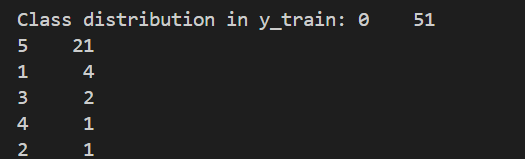
<br>
<p>This issue was fixed by increasing the iterations. The following table shows the MCC for different approaches.<p><br>

|Method|n_estimator|MCC|
|:----------|----:|----:
|logistic|-|0.0|
|Random forest|100|-0.00012597255459172648 |
|Random forest_balanced class|100|0.0031726493157015288|
|Random forest_balanced class|200|0.003108056364704113|

While the MCC does lean more to the positive, it is still very close to 0.0. Meaning, the predictions are no better than random.

The following tabel shows a Classification report for the approach: Random forest with balanced classes and 200 decision trees.<br>


|           |   0 |   1 |   2 |   3 |   4 |   6 |   7 |   11 |   12 |   14 |   21 |   25 |   33 |   36 |   37 |   39 |   40 |   43 |   44 |   45 |   46 |   48 |   51 |   53 |   54 |   56 |   57 |   59 |   60 |   62 |   64 |       68 |   71 |   72 |   73 |   75 |   80 |   82 |   83 |   89 |   90 |   92 |   93 |   95 |   100 |   102 |   103 |   104 |   110 |   112 |   113 |   114 |   115 |   116 |   117 |   120 |   121 |   122 |   123 |   125 |   127 |   129 |   131 |   132 |   134 |   136 |   137 |   139 |   142 |   143 |   144 |   145 |   149 |   150 |   152 |   154 |   156 |   157 |   160 |   161 |   162 |   164 |   166 |   168 |   170 |   173 |   174 |   176 |   177 |   178 |   180 |   182 |   183 |   184 |   185 |   186 |   189 |   193 |   194 |   195 |   196 |   197 |   199 |   201 |   202 |   204 |   205 |   206 |   211 |   212 |   213 |   216 |   217 |   218 |   219 |   222 |   225 |   226 |   228 |   229 |   230 |   231 |   232 |   233 |   235 |   236 |   237 |   239 |   240 |   243 |   244 |   245 |   246 |   248 |   251 |   252 |   253 |   254 |   255 |   256 |   259 |   263 |   264 |   265 |   266 |   267 |   269 |   271 |   282 |   283 |   284 |   286 |   288 |   290 |   291 |   292 |   305 |   309 |   313 |   315 |   317 |   322 |   327 |   328 |   329 |   330 |   331 |   333 |   336 |   337 |   338 |   340 |   346 |   350 |   351 |   353 |   355 |   356 |   360 |   361 |   362 |   363 |   364 |   365 |   366 |   369 |   372 |   375 |   376 |   378 |   379 |   382 |   385 |   387 |   389 |   393 |   395 |   396 |   399 |   400 |   404 |   405 |   407 |   409 |   411 |   414 |   415 |   416 |   422 |   423 |   424 |   425 |   426 |   430 |   431 |   439 |   442 |   443 |   444 |   445 |   446 |   449 |   450 |   451 |   452 |   453 |   456 |   457 |   460 |   461 |   463 |   464 |   465 |   467 |   468 |   469 |   471 |   472 |   473 |   474 |   476 |   477 |   480 |   481 |   482 |   484 |   485 |   486 |   487 |   489 |   491 |   492 |   493 |   494 |   495 |   497 |   498 |   500 |   501 |   504 |   505 |   506 |   508 |   509 |   513 |   514 |   516 |   517 |   518 |   519 |   520 |   522 |   526 |   529 |   531 |   534 |   536 |   537 |   539 |   540 |   541 |   545 |   546 |   548 |   549 |   550 |   552 |   554 |   555 |   557 |   565 |   566 |   571 |   576 |   581 |   582 |   583 |   584 |   585 |   587 |   588 |   589 |   590 |   597 |   598 |   610 |   615 |   622 |   623 |   627 |   628 |   631 |   635 |   649 |   653 |   654 |   658 |   663 |   666 |   669 |   670 |   673 |   674 |   675 |   677 |   681 |   682 |   683 |   685 |   687 |   688 |   689 |   695 |   700 |   703 |   704 |   705 |   706 |   707 |   709 |   710 |   711 |   712 |   715 |   716 |   718 |   719 |   721 |   723 |   724 |   726 |   727 |   728 |   730 |   732 |   733 |   734 |   735 |   737 |   753 |   755 |   756 |   757 |   758 |   759 |   760 |   761 |   762 |   763 |   764 |   765 |   767 |   777 |   778 |   779 |   780 |   782 |   785 |   787 |   788 |   789 |   790 |        791 |   793 |   794 |   795 |   799 |   801 |   804 |   805 |   806 |   807 |   808 |   811 |   812 |   813 |   815 |   816 |   817 |   820 |   821 |   823 |   824 |   825 |   826 |   827 |   832 |   833 |   834 |   835 |   836 |   837 |   838 |   840 |   842 |   843 |   844 |   845 |   846 |   847 |   848 |   849 |   850 |   851 |   852 |   855 |   856 |   862 |   863 |   864 |   865 |   866 |   867 |   873 |   875 |   879 |   880 |   881 |   886 |   891 |   895 |   896 |   900 |   904 |   905 |   907 |   909 |   910 |   913 |   accuracy |      macro avg |   weighted avg |
|:----------|----:|----:|----:|----:|----:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|---------:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|-----------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|-----------:|---------------:|---------------:|
| precision |   0 |   0 |   0 |   0 |   0 |   0 |   0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 | 0.166667 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |  0.0102512 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0.0105 |    0.000394026 |    0.000185845 |
| recall    |   0 |   0 |   0 |   0 |   0 |   0 |   0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 | 1        |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |  1         |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0.0105 |    0.00445434  |    0.0105      |
| f1-score  |   0 |   0 |   0 |   0 |   0 |   0 |   0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 | 0.285714 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |    0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |  0.0202943 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0 |     0.0105 |    0.000681534 |    0.0003458   |
| support   |   1 |   1 |   2 |   1 |   1 |   3 |   1 |    2 |    2 |    1 |    2 |    1 |    4 |    2 |    1 |    1 |    1 |    1 |    1 |    1 |    2 |    2 |    1 |    1 |    1 |    1 |    1 |    2 |    1 |    2 |    3 | 1        |    3 |    5 |    1 |    1 |    2 |    1 |    4 |    2 |    1 |    2 |    1 |    1 |     1 |     3 |     3 |     3 |     2 |     1 |     2 |     4 |     2 |     2 |     2 |     1 |     2 |     2 |     1 |     1 |     1 |     4 |     4 |     3 |     1 |     1 |     6 |     6 |     2 |     2 |     1 |     1 |     1 |     1 |     1 |     1 |     7 |     1 |     4 |     1 |     2 |     2 |     1 |     1 |     2 |     2 |     6 |     1 |     1 |     1 |     3 |     2 |     2 |     1 |     1 |     1 |     2 |     1 |     1 |     3 |     3 |     2 |     2 |     1 |     4 |     2 |     2 |     2 |     4 |     3 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     3 |     2 |     3 |     1 |     3 |     2 |     4 |     7 |     4 |     2 |     8 |     1 |     2 |     2 |     4 |     2 |     4 |     3 |     2 |     3 |     1 |     2 |     1 |     1 |     1 |     3 |     3 |     1 |     3 |     1 |     2 |     3 |     2 |     1 |     5 |     1 |     1 |     1 |     3 |     1 |     3 |     1 |     1 |     2 |     2 |     1 |     1 |     4 |     1 |     3 |     5 |     1 |     2 |     1 |     1 |     1 |     7 |     1 |     2 |     2 |     5 |     2 |     1 |     1 |     1 |     1 |     1 |     2 |     1 |     1 |     2 |     1 |     2 |    18 |     1 |     2 |     1 |     1 |     1 |     1 |     2 |     3 |     2 |     2 |     1 |     2 |     1 |     1 |     1 |     2 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     3 |     2 |    11 |     2 |     1 |     1 |     1 |     2 |     1 |    13 |     3 |     2 |     1 |     1 |     1 |     1 |     5 |     1 |     1 |     6 |     1 |     2 |     2 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     2 |     4 |     1 |     3 |     3 |    10 |     1 |     1 |     6 |     1 |     1 |     1 |     1 |     1 |     3 |     1 |     1 |     1 |     2 |     1 |     2 |     2 |     2 |     2 |     1 |     1 |     1 |     1 |     7 |    11 |     1 |     2 |     4 |     1 |     2 |     1 |     2 |     1 |     2 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     1 |     2 |     1 |     1 |     2 |     2 |     1 |     2 |     1 |     1 |     1 |     3 |     1 |     1 |     3 |     2 |     1 |     3 |     1 |     2 |     2 |     5 |     1 |     2 |     2 |     1 |     1 |     1 |     1 |     4 |     3 |     1 |     1 |     1 |     1 |     1 |     1 |     2 |     1 |     1 |     1 |     2 |     1 |     1 |     7 |     4 |     2 |     1 |     5 |     2 |     2 |   129 |     1 |     2 |    19 |    22 |    21 |    21 |    40 |    19 |     3 |     8 |     2 |     1 |     1 |     1 |    12 |    25 |    21 |    18 |    21 |    26 |    16 |    21 |    40 |    22 |    25 |     2 |     1 |     1 |    18 |    25 |     1 |     1 |    15 |     1 |    11 |    26 | 20         |    14 |     9 |     1 |     1 |     1 |    21 |    34 |    24 |     1 |     4 |     1 |    11 |    28 |     1 |     1 |     1 |     1 |     1 |     2 |     1 |    24 |    14 |    21 |    14 |    25 |    15 |    36 |    20 |     2 |    31 |     3 |    16 |     1 |     3 |     1 |    24 |    23 |    21 |    26 |    19 |    22 |    34 |     1 |     1 |     1 |     1 |     6 |     1 |    35 |     1 |     1 |     1 |     1 |     1 |    21 |     1 |     2 |     1 |     1 |     2 |     1 |     2 |     1 |     4 |     2 |     1 |     0.0105 | 2000           | 2000           |
<br>


## Possible Solutions

Fixing the RAM issues should be the main priority, as they are likely to be a recurring problem. A quick and efficient solution is necessary to ensure this process of embedding and etc. can continue.

Another important step is verifying the validity of the data itself. For instance, confirming  whether the Kidera factors are arctually informative and normalized. Additionally, if the feature space is too noisy or sparse, applying dimensionality reduction techniques such as PCA could help reduce data noise and improve model performance.
[Other kidera factors](https://github.com/vadimnazarov/kidera-atchley/blob/master/kidera.txt) from a different source were also used later, in case there was a misunderstanding on what these factors actually entain. The result was still similar to the other approaches. Thus, the error could not lie in the kidera factors themselves.

Another possibility is that, errors occurred during the initial data processing steps. False mapping or incorrect embedding might have happened without initial notice. These issues could render the data unsuitable for further use. Therefore further investigating is necessary


## Additional Data

New kidera values, that might be the actual correct ones:

In [ ]:
kidera_dict = {
    'A': [-1.56, -1.67, -0.97, -0.27, -0.93, -0.78, -0.2, -0.08, 0.21, -0.48],
    'R': [0.22, 1.27, 1.37, 1.87, -1.7, 0.46, 0.92, -0.39, 0.23, 0.93],
    'N': [1.14, -0.07, -0.12, 0.81, 0.18, 0.37, -0.09, 1.23, 1.1, -1.73],
    'D': [0.58, -0.22, -1.58, 0.81, -0.92, 0.15, -1.52, 0.47, 0.76, 0.7],
    'C': [0.12, -0.89, 0.45, -1.05, -0.71, 2.41, 1.52, -0.69, 1.13, 1.1],
    'Q': [-0.47, 0.24, 0.07, 1.1, 1.1, 0.59, 0.84, -0.71, -0.03, -2.33],
    'E': [-1.45, 0.19, -1.61, 1.17, -1.31, 0.4, 0.04, 0.38, -0.35, -0.12],
    'G': [1.46, -1.96, -0.23, -0.16, 0.1, -0.11, 1.32, 2.36, -1.66, 0.46],
    'H': [-0.41, 0.52, -0.28, 0.28, 1.61, 1.01, -1.85, 0.47, 1.13, 1.63],
    'I': [-0.73, -0.16, 1.79, -0.77, -0.54, 0.03, -0.83, 0.51, 0.66, -1.78],
    'L': [-1.04, 0, -0.24, -1.1, -0.55, -2.05, 0.96, -0.76, 0.45, 0.93],
    'K': [-0.34, 0.82, -0.23, 1.7, 1.54, -1.62, 1.15, -0.08, -0.48, 0.6],
    'M': [-1.4, 0.18, -0.42, -0.73, 2, 1.52, 0.26, 0.11, -1.27, 0.27],
    'F': [-0.21, 0.98, -0.36, -1.43, 0.22, -0.81, 0.67, 1.1, 1.71, -0.44],
    'P': [2.06, -0.33, -1.15, -0.75, 0.88, -0.45, 0.3, -2.3, 0.74, -0.28],
    'S': [0.81, -1.08, 0.16, 0.42, -0.21, -0.43, -1.89, -1.15, -0.97, -0.23],
    'T': [0.26, -0.7, 1.21, 0.63, -0.1, 0.21, 0.24, -1.15, -0.56, 0.19],
    'W': [0.3, 2.1, -0.72, -1.57, -1.16, 0.57, -0.48, -0.4, -2.3, -0.6],
    'Y': [1.38, 1.48, 0.8, -0.56, 0, -0.68, -0.31, 1.03, -0.05, 0.53],
    'V': [-0.74, -0.71, 2.04, -0.4, 0.5, -0.81, -1.07, 0.06, -0.46, 0.65],
    'B': [0] * 10  # Padding character vector
}